Ten skrypt tworzy system wizualizacji danych z automatycznym ulepszaniem, gdzie agent FigureCreator koordynuje współpracę trzech agentów: komendera (wykonuje kod), krytyka (ocenia wykresy) i programisty (modyfikuje kod). System iteracyjnie poprawia wizualizacje na podstawie krytyki, z przykładem tworzenia wykresu temperatury z danych CSV.

# Setup

In [ ]:
!uv pip install -q autogen matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 787.5/787.5 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.5 MB/s eta 0:00:00


`autogen matplotlib` to nazwy pakietów, które mają zostać zainstalowane.
*   `autogen` to biblioteka służąca do automatycznego generowania kodu, często wykorzystywana w kontekście agentów autonomicznych.
*   `matplotlib` to popularna biblioteka do tworzenia wykresów i wizualizacji danych w Pythonie.

In [ ]:
import os

import matplotlib.pyplot as plt
from PIL import Image

from google.colab import userdata

import autogen
from autogen import Agent, AssistantAgent, ConversableAgent
from autogen.agentchat.contrib.multimodal_conversable_agent import (
    MultimodalConversableAgent,
)

*   **`autogen`**: Główna biblioteka, która jest importowana. Służy do tworzenia i zarządzania agentami autonomicznymi.
*   **`autogen.Agent`, `autogen.AssistantAgent`, `autogen.ConversableAgent`, `autogen.UserProxyAgent`**: Klasy z biblioteki `autogen` reprezentujące różne typy agentów.
*   **`autogen.agentchat.contrib.multimodal_conversable_agent.MultimodalConversableAgent`**: Klasa agenta zdolnego do przetwarzania różnych rodzajów danych, w tym tekstu i obrazów.

In [ ]:
# configs
openai_api = userdata.get("openaivision")

In [ ]:
config_list_4v = [{"model": "gpt-4o-mini", "api_key": openai_api}]

config_list_gpt4 = [{"model": "gpt-4o-mini", "api_key": openai_api}]

gpt4_llm_config = {"config_list": config_list_gpt4, "cache_seed": 42}

# Functions

In [6]:
working_dir = "/content/tmp/"

In [ ]:
class FigureCreator(ConversableAgent):
    def __init__(self, n_iters=2, **kwargs):
        """
        Initializes a FigureCreator instance.

        This agent facilitates the creation of visualizations through a collaborative effort among its child agents: commander, coder, and critics.

        Parameters:
            - n_iters (int, optional): The number of "improvement" iterations to run. Defaults to 2.
            - **kwargs: keyword arguments for the parent AssistantAgent.
        """
        super().__init__(**kwargs)
        self.register_reply(
            [Agent, None], reply_func=FigureCreator._reply_user, position=0
        )
        self._n_iters = n_iters

    def _reply_user(self, messages=None, sender=None, config=None):
        if all((messages is None, sender is None)):
            error_msg = f"Either {messages=} or {sender=} must be provided."
            raise AssertionError(error_msg)
        if messages is None:
            messages = self._oai_messages[sender]

        user_question = messages[-1]["content"]

        ### Define the agents
        commander = AssistantAgent(
            name="Commander",
            human_input_mode="NEVER",
            max_consecutive_auto_reply=10,
            system_message="Help me run the code, and tell other agents it is in the <img result.jpg> file location.",
            is_termination_msg=lambda x: x.get("content", "")
            .rstrip()
            .endswith("TERMINATE"),
            code_execution_config={
                "last_n_messages": 3,
                "work_dir": working_dir,
                "use_docker": False,
            },
            llm_config=self.llm_config,
        )

        critics = MultimodalConversableAgent(
            name="Critics",
            system_message="""Criticize the input figure. How to replot the figure so it will be better? Find bugs and issues for the figure.
            Pay attention to the color, format, and presentation. Keep in mind of the reader-friendliness.
            If you think the figures is good enough, then simply say NO_ISSUES""",
            llm_config={"config_list": config_list_4v, "max_tokens": 300},
            human_input_mode="NEVER",
            max_consecutive_auto_reply=1,
        )

        coder = AssistantAgent(
            name="Coder",
            llm_config=self.llm_config,
        )

        coder.update_system_message(
            coder.system_message
            + "ALWAYS save the figure in `result.jpg` file. Tell other agents it is in the <img result.jpg> file location."
        )

        # Data flow begins
        commander.initiate_chat(coder, message=user_question)
        img = Image.open(os.path.join(working_dir, "result.jpg"))
        plt.imshow(img)
        plt.axis("off")  # Hide the axes
        plt.show()

        for i in range(self._n_iters):
            commander.send(
                message=f"Improve <img {os.path.join(working_dir, 'result.jpg')}>",
                recipient=critics,
                request_reply=True,
            )

            feedback = commander._oai_messages[critics][-1]["content"]
            if feedback.find("NO_ISSUES") >= 0:
                break
            commander.send(
                message="Here is the feedback to your figure. Please improve! Save the result to `result.jpg`\n"
                + feedback,
                recipient=coder,
                request_reply=True,
            )
            img = Image.open(os.path.join(working_dir, "result.jpg"))
            plt.imshow(img)
            plt.axis("off")
            plt.show()

        return True, os.path.join(working_dir, "result.jpg")

Klasa `FigureCreator` automatyzuje proces tworzenia i ulepszania wykresów poprzez koordynację pracy trzech agentów: komendera, krytyka i programisty.  Proces iteracyjny pozwala na stopniowe poprawianie jakości wizualizacji na podstawie informacji zwrotnych od krytyków.

# Test

User (to FigureCreator):


Plot a figure by using the data from:
https://raw.githubusercontent.com/vega/vega/main/docs/data/seattle-weather.csv

I want to show both temperature high and low. Only use the first 50 observations.


--------------------------------------------------------------------------------
Commander (to Coder):


Plot a figure by using the data from:
https://raw.githubusercontent.com/vega/vega/main/docs/data/seattle-weather.csv

I want to show both temperature high and low. Only use the first 50 observations.


--------------------------------------------------------------------------------
Coder (to Commander):

To achieve this task, I will follow these steps:

1. Download the CSV data from the provided URL.
2. Read the CSV data and extract the first 50 observations for temperature high and low.
3. Use a plotting library to create a figure that shows both the temperature high and low.
4. Save the figure as `result.jpg`.

Let me proceed with the implementation now. 


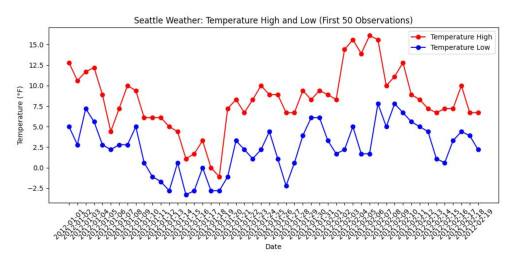

Commander (to Critics):

Improve <image>

--------------------------------------------------------------------------------
Critics (to Commander):

Here are some suggestions to improve the plot:

1. **X-axis Labeling**: The dates are squished and overlapping, which makes them hard to read. Consider rotating the x-axis labels (e.g., by 45 or 90 degrees) or using fewer ticks to avoid clutter.

2. **Y-axis Scaling**: The range of temperatures may benefit from adjusting the y-axis limits to better fit the data, making it easier to see variations without distraction from excessive empty space.

3. **Line Thickness**: Increasing the thickness of the lines can make them more prominent and easier to follow.

4. **Point Markers**: Different shapes for each temperature dataset (e.g., circles for highs and squares for lows) could enhance clarity, especially for viewers who may have color vision deficiencies.

5. **Gridlines**: Adding horizontal gridlines could improve readability and help viewers

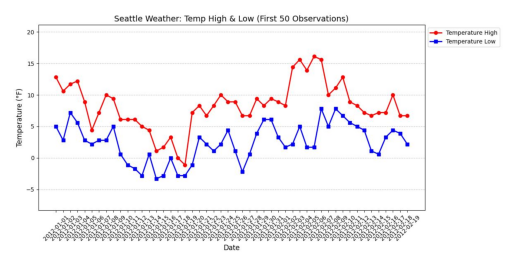

Commander (to Critics):

Improve <image>

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (3e548be5-9569-4a6b-9ef5-f51eac0463c8): Maximum number of consecutive auto-replies reached
Commander (to Coder):

Here is the feedback to your figure. Please improve! Save the result to `result.jpg`
Improve <img /content/tmp/result.jpg>

--------------------------------------------------------------------------------
Coder (to Commander):

To further enhance the plot based on your feedback, I will implement the following improvements:

1. **Background Color**: Change the background color to a lighter shade to improve contrast and visibility.
2. **Points for Different Seasons**: Mark points with different colors or shapes to indicate seasonal variations, if applicable.
3. **Change the Marker Style**: Use more distinct markers for better clarity, especially when the lines are close.
4. **Tighten the Date Range**: If the dataset allows, consi

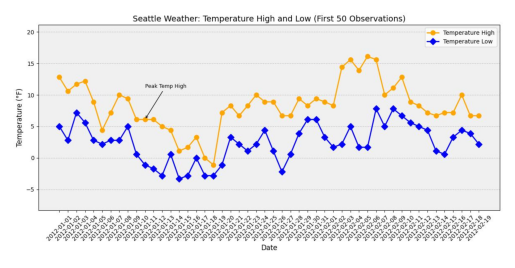

FigureCreator (to User):

/content/tmp/result.jpg

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (d190b22b-e24a-45d4-949d-6720df7f88f0): Maximum number of consecutive auto-replies reached


ChatResult(chat_id=None, chat_history=[{'content': '\nPlot a figure by using the data from:\nhttps://raw.githubusercontent.com/vega/vega/main/docs/data/seattle-weather.csv\n\nI want to show both temperature high and low. Only use the first 50 observations.\n', 'role': 'assistant', 'name': 'User'}, {'content': '/content/tmp/result.jpg', 'role': 'user', 'name': 'FigureCreator'}], summary='/content/tmp/result.jpg', cost={'usage_including_cached_inference': {'total_cost': 0}, 'usage_excluding_cached_inference': {'total_cost': 0}}, human_input=[])

In [ ]:
creator = FigureCreator(name="FigureCreator", llm_config=gpt4_llm_config)

user_proxy = autogen.UserProxyAgent(
    name="User",
    human_input_mode="NEVER",
    max_consecutive_auto_reply=0,
    code_execution_config={"use_docker": False},
)

user_proxy.initiate_chat(
    creator,
    message="""
Plot a figure by using the data from:
https://raw.githubusercontent.com/vega/vega/main/docs/data/seattle-weather.csv

I want to show both temperature high and low. Only use the first 50 observations.
""",
)